# PickMeal - baselibe model, first ML-model

## Important
This notebook has **two different parts**:

- **metrics parser v1 / parser v2** - this is the quality of the final parser menu by dishes;
- **metrics line role classifier** - this is the quality of th separate model that defindes the type of an OCR-line (`section`, `item_name`, `description`, `price`, `noise`).

So this is different tasks and metrics shouldn't be compared.


In [14]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "reports").exists() and (PROJECT_ROOT.parent / "reports").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent


## 1. Load the metrics of parser baseline

In [16]:
def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

def try_load_parser_comparison():
    comparison_csv = PROJECT_ROOT / "reports" / "parser_comparison" / "parser_v1_vs_v2.csv"
    if comparison_csv.exists():
        return pd.read_csv(comparison_csv)

    # fallback - building from json
    paths = [
        (PROJECT_ROOT / "reports" / "parser_baseline" / "parser_metrics_valid.json", "Parser v1 valid"),
        (PROJECT_ROOT / "reports" / "parser_baseline" / "parser_metrics_test.json", "Parser v1 test"),
        (PROJECT_ROOT / "reports" / "parser_baseline_v2" / "parser_metrics_valid.json", "Parser v2 valid"),
        (PROJECT_ROOT / "reports" / "parser_baseline_v2" / "parser_metrics_test.json", "Parser v2 test"),
    ]
    rows = []
    for path, label in paths:
        if path.exists():
            row = load_json(path)
            row["label"] = label
            rows.append(row)
    return pd.DataFrame(rows)

parser_df = try_load_parser_comparison()
parser_df

,label,n_menus,item_precision,item_recall,item_f1,section_accuracy,price_accuracy,description_exact_match,item_tp,item_fp,item_fn
0,Parser v1 valid,7,0.3037,0.3009,0.3023,0.0615,0.4074,0.0,65,149,151
1,Parser v1 test,8,0.2955,0.3318,0.3126,0.0000,0.3333,0.0,73,174,147
2,Parser v2 valid,7,0.5751,0.6204,0.5969,0.6716,0.5948,0.0,134,99,82
3,Parser v2 test,8,0.4118,0.6045,0.4899,0.5192,0.2756,0.0,133,190,87


In [17]:
display_cols = [
    "label", "item_precision", "item_recall", "item_f1",
    "section_accuracy", "price_accuracy", "description_exact_match",
    "item_tp", "item_fp", "item_fn",
]
parser_table = parser_df[display_cols].copy()
parser_table

,label,item_precision,item_recall,item_f1,section_accuracy,price_accuracy,description_exact_match,item_tp,item_fp,item_fn
0,Parser v1 valid,0.3037,0.3009,0.3023,0.0615,0.4074,0.0,65,149,151
1,Parser v1 test,0.2955,0.3318,0.3126,0.0000,0.3333,0.0,73,174,147
2,Parser v2 valid,0.5751,0.6204,0.5969,0.6716,0.5948,0.0,134,99,82
3,Parser v2 test,0.4118,0.6045,0.4899,0.5192,0.2756,0.0,133,190,87


### Quality parser v1 and parser v2 with main metrcis

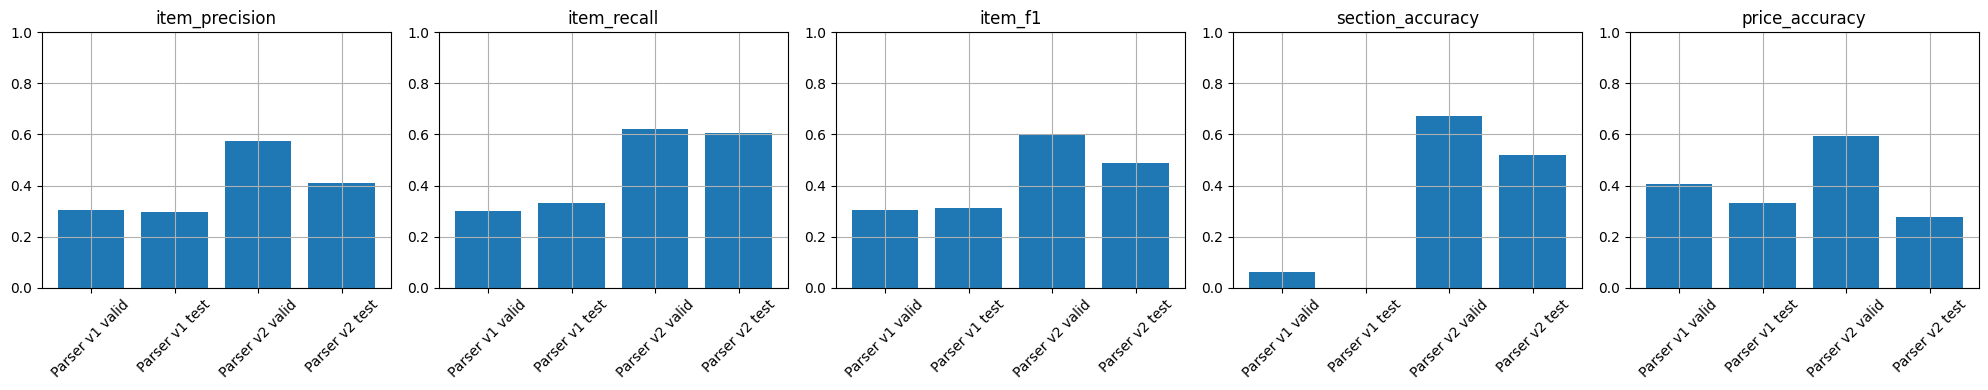

In [18]:
plot_df = parser_df.copy()
metrics = ["item_precision", "item_recall", "item_f1", "section_accuracy", "price_accuracy"]
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 4))
for ax, metric in zip(axes, metrics):
    ax.bar(plot_df["label"], plot_df[metric])
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Parser baseline output

- `parser v2` is significantly better than `parser v1` for `item_f1` and `section_accuracy`;
- but parsing is still weak, especially for price and description;
- this means the rule-based baseline has improved, but the rule ceiling is already visible.

This is a good and fair baseline result for the next step.

## 2. First train model: classification of menu lines

In [19]:
line_role_metrics_path = PROJECT_ROOT / "reports" / "line_role_baseline" / "line_role_metrics.json"
line_role_report_path = PROJECT_ROOT / "reports" / "line_role_baseline" / "line_role_classification_report.json"
line_role_cm_path = PROJECT_ROOT / "reports" / "line_role_baseline" / "line_role_confusion_matrix.csv"
line_role_stats_path = PROJECT_ROOT / "data" / "processed" / "gold" / "line_role_dataset_stats.json"

line_role_metrics = load_json(line_role_metrics_path) if line_role_metrics_path.exists() else {}
line_role_report = load_json(line_role_report_path) if line_role_report_path.exists() else {}
line_role_stats = load_json(line_role_stats_path) if line_role_stats_path.exists() else {}
line_role_cm = pd.read_csv(line_role_cm_path, index_col=0) if line_role_cm_path.exists() else pd.DataFrame()

line_role_metrics, line_role_stats

({'n_train_rows': 1685,
  'n_test_rows': 490,
  'n_train_menus': 31,
  'n_test_menus': 8,
  'accuracy': 0.8224,
  'macro_f1': 0.7656,
  'weighted_f1': 0.8255},
 {'description': 40,
  'item_name': 699,
  'noise': 891,
  'price': 485,
  'section': 60})

### Distibution of classes in train set

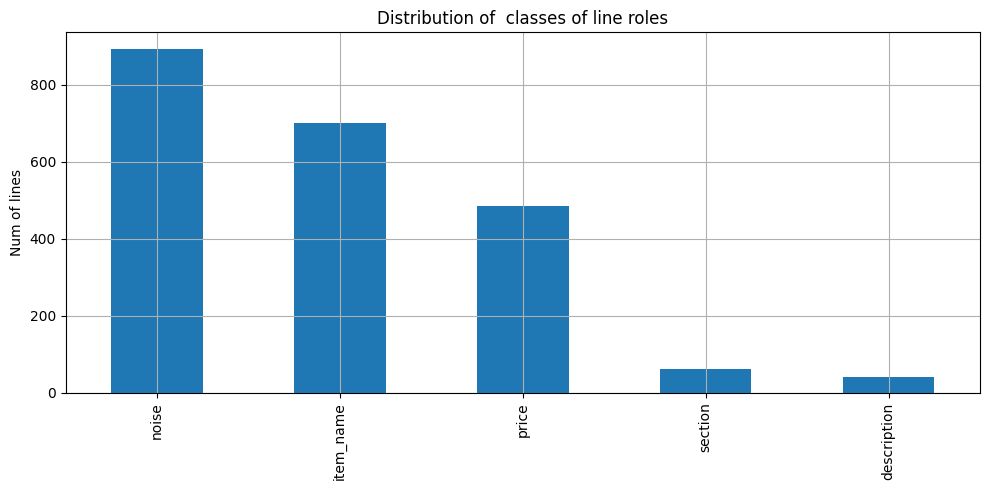

,count
noise,891
item_name,699
price,485
section,60
description,40


In [20]:
stats_series = pd.Series(line_role_stats).sort_values(ascending=False)
ax = stats_series.plot(kind="bar", title="Distribution of  classes of line roles")
ax.set_ylabel("Num of lines")
plt.tight_layout()
plt.show()
display(stats_series.rename("count").to_frame())

### Common metrics of the first model

,n_train_rows,n_test_rows,n_train_menus,n_test_menus,accuracy,macro_f1,weighted_f1
0,1685,490,31,8,0.8224,0.7656,0.8255


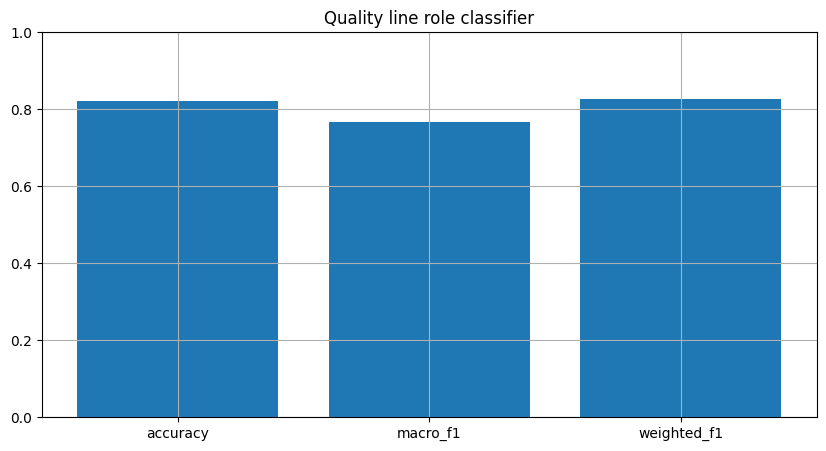

In [21]:
metrics_df = pd.DataFrame(
    {
        "metric": ["accuracy", "macro_f1", "weighted_f1"],
        "value": [
            line_role_metrics.get("accuracy"),
            line_role_metrics.get("macro_f1"),
            line_role_metrics.get("weighted_f1"),
        ],
    }
)
display(pd.DataFrame([line_role_metrics]))
ax = plt.bar(metrics_df["metric"], metrics_df["value"])
plt.ylim(0, 1)
plt.title("Quality line role classifier")
plt.show()

### Confusion matrix

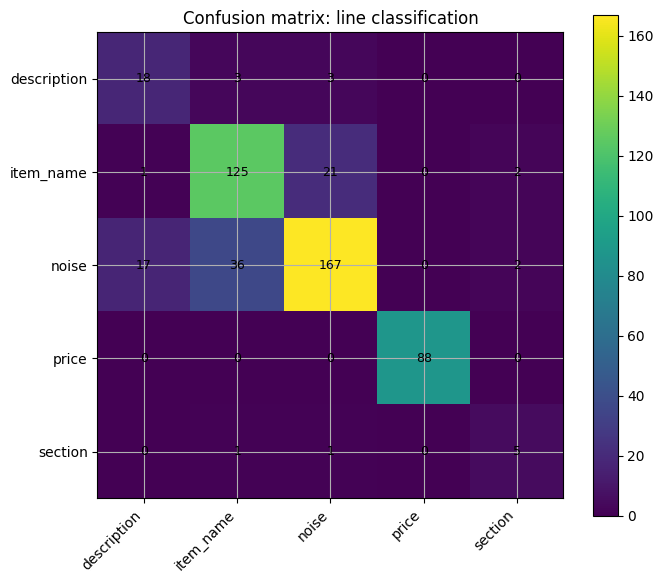

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(line_role_cm.values)
ax.set_xticks(range(len(line_role_cm.columns)))
ax.set_xticklabels(line_role_cm.columns, rotation=45, ha="right")
ax.set_yticks(range(len(line_role_cm.index)))
ax.set_yticklabels(line_role_cm.index)
ax.set_title("Confusion matrix: line classification")
for i in range(line_role_cm.shape[0]):
    for j in range(line_role_cm.shape[1]):
        ax.text(j, i, str(line_role_cm.iloc[i, j]), ha="center", va="center", fontsize=9)
plt.colorbar(im)
plt.tight_layout()
plt.show()

### Conclusion for the first ML model

According to the current results, the string classification model yields:

- `accuracy = 0.8224`
- `macro_f1 = 0.7656`
- `weighted_f1 = 0.8255`

This is a **good first ML baseline**, especially because the classes are unbalanced:
- `description` and `section` are noticeably underrepresented,
- `noise` and `item_name` are much more common.
